# Ordination: nMDS and Metric MDS (PCoA)

## Overview

Ordination places observations in low-dimensional space so that their distances reflect dissimilarities in the original data. Unlike PCA, ordination works with any dissimilarity metric — making it the standard approach in community ecology, where Euclidean distance is often ecologically inappropriate.

**Two key methods:**

| Method | Approach | Key property |
|---|---|---|
| **Metric MDS (PCoA)** | Eigendecomposition of a distance matrix | Exact representation; equivalent to PCA on Euclidean distances |
| **nMDS** | Iterative rank-order optimisation | Uses rank of distances only; more flexible; standard in ecology |

**nMDS key properties:**
- Works with any dissimilarity matrix (Bray-Curtis, Jaccard, Gower…)
- Preserves **rank order** of dissimilarities, not magnitudes
- Convergence measured by **stress**: 0 = perfect; < 0.10 = good; < 0.20 = acceptable; > 0.20 = suspect
- Axes are arbitrary — no variance-explained interpretation
- Always run multiple random starts to avoid local minima

**Bray-Curtis dissimilarity** is standard for species abundance data: it is bounded [0,1], ignores joint absences, and is proportionally scaled. Use `vegan::vegdist()`.

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(vegan)         # metaMDS(), vegdist(), envfit(), adonis2()
library(ggvegan)       # autoplot() for vegan objects
library(patchwork)

set.seed(42)

# ── Species × site matrix with environmental gradient ─────────────────────────
n_sites   <- 45
n_species <- 15

make_community <- function(type, n) {
  base <- switch(type,
    "reference" = c(10,8,7,6,5,4,3,2,1,0,0,0,0,0,0),
    "restored"  = c(4,4,4,4,4,3,3,2,2,2,1,1,0,0,0),
    "degraded"  = c(0,0,0,0,1,1,2,2,3,4,5,6,7,8,9)
  )
  t(replicate(n, pmax(0, round(base + rnorm(n_species, 0, 1.8)))))
}

comm_mat <- rbind(
  make_community("reference", 15),
  make_community("restored",  15),
  make_community("degraded",  15)
)
rownames(comm_mat) <- paste0(rep(c("ref","res","deg"), each=15), "_", 1:45)
colnames(comm_mat) <- paste0("sp", 1:n_species)

site_meta <- tibble(
  site      = rownames(comm_mat),
  type      = rep(c("reference","restored","degraded"), each=15),
  nitrate   = c(rnorm(15,2,0.5), rnorm(15,5,0.7), rnorm(15,9,0.9)),
  water_qual= c(rnorm(15,8,0.6), rnorm(15,5,0.8), rnorm(15,2.5,0.7))
)
cat(sprintf("Community matrix: %d sites × %d species\n",
            nrow(comm_mat), ncol(comm_mat)))

Warning message:
"package 'ggvegan' was built under R version 4.4.3"


Warning message:
"package 'patchwork' was built under R version 4.4.3"


Community matrix: 45 sites × 15 species


---

## nMDS

nMDS Stress: 0.0921


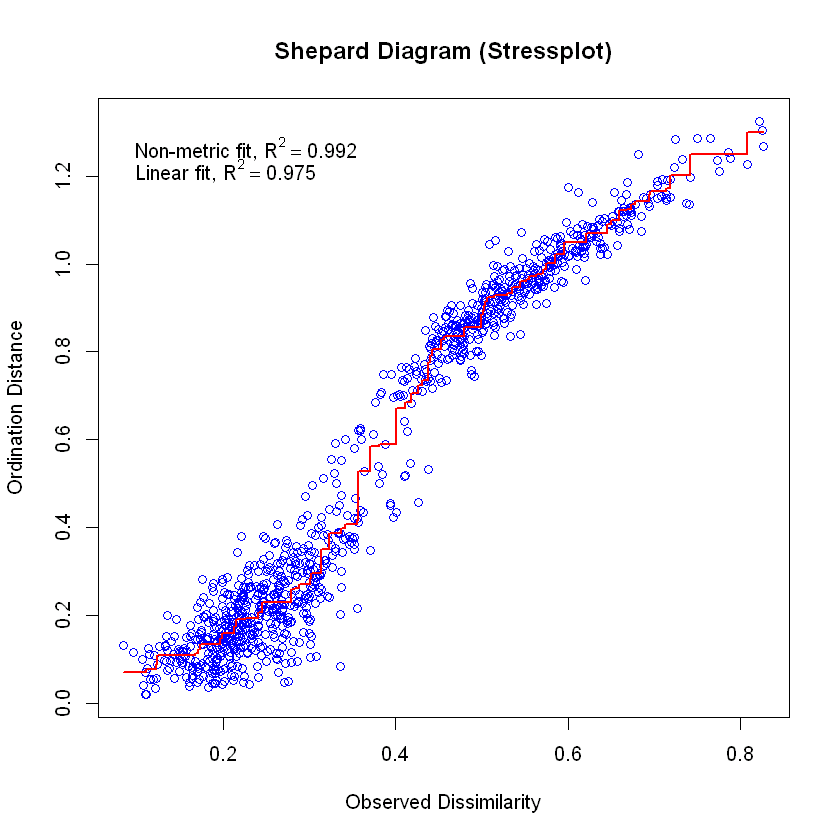

In [4]:
# Hellinger transformation before Bray-Curtis is recommended for
# sparse matrices: square-root of relative abundances
comm_hel  <- vegan::decostand(comm_mat, method="hellinger")
bray_dist <- vegan::vegdist(comm_hel, method="bray")

# metaMDS: automatic number-of-starts + stress convergence
# trymax=100: up to 100 random starts to find global minimum
nmds_fit <- vegan::metaMDS(
  comm_hel,
  distance = "bray",
  k        = 2,        # 2 dimensions; try k=3 if stress > 0.2
  trymax   = 100,
  autotransform = FALSE,  # we already applied Hellinger
  trace    = FALSE
)

cat(sprintf("nMDS Stress: %.4f\n", nmds_fit$stress))
# Stress < 0.05: excellent; < 0.10: good; < 0.20: acceptable; > 0.20: suspect

# Stressplot (Shepard diagram)
vegan::stressplot(nmds_fit, main="Shepard Diagram (Stressplot)")
# Points on the step-function line = perfect rank preservation
# Scatter around the line = stress; R² shown in top-left

---

## Ordination Plot with Environmental Vectors


***VECTORS

              NMDS1    NMDS2     r2 Pr(>r)    
nitrate     0.93013 -0.36723 0.8668  0.001 ***
water_qual -0.81275  0.58261 0.7624  0.001 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Permutation: free
Number of permutations: 999




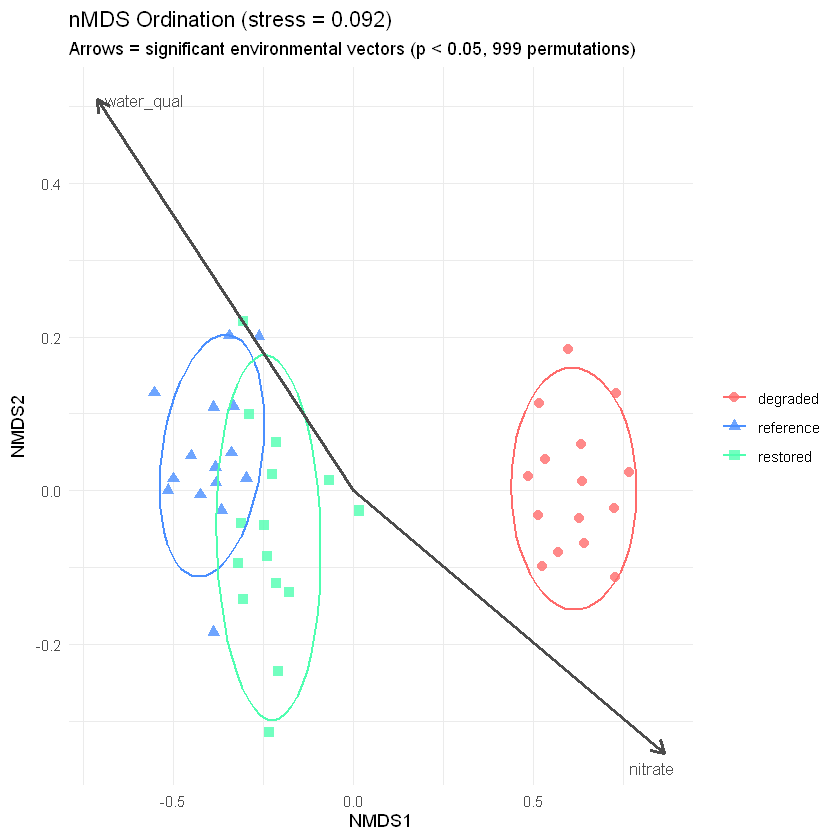

In [5]:
# envfit: fit environmental variables onto the ordination
# Projects each variable as a vector in ordination space
env_vars <- site_meta %>% select(nitrate, water_qual) %>% as.data.frame()

env_fit  <- vegan::envfit(
  nmds_fit,
  env      = env_vars,
  permutations = 999,
  seed     = 42
)
print(env_fit)
# r2: squared correlation between variable and ordination axis
# Pr: permutation p-value

# ── Ordination plot ───────────────────────────────────────────────────────────
scores_df <- as_tibble(vegan::scores(nmds_fit, display="sites"),
                       rownames="site") %>%
  left_join(site_meta, by="site")

env_vectors <- as_tibble(vegan::scores(env_fit, display="vectors"),
                          rownames="variable") %>%
  mutate(p_val = env_fit$vectors$pvals)

ggplot(scores_df, aes(x=NMDS1, y=NMDS2)) +
  geom_point(aes(color=type, shape=type), size=2.5, alpha=0.8) +
  stat_ellipse(aes(color=type), level=0.85, linewidth=0.8) +
  geom_segment(
    data = env_vectors %>% filter(p_val < 0.05),
    aes(x=0, y=0, xend=NMDS1, yend=NMDS2),
    arrow=arrow(length=unit(0.3,"cm")), color="gray30", linewidth=1
  ) +
  ggrepel::geom_text_repel(
    data = env_vectors %>% filter(p_val < 0.05),
    aes(x=NMDS1, y=NMDS2, label=variable),
    color="gray30", size=3.5
  ) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ff6b6b")) +
  labs(
    title    = sprintf("nMDS Ordination (stress = %.3f)", nmds_fit$stress),
    subtitle = "Arrows = significant environmental vectors (p < 0.05, 999 permutations)",
    color=NULL, shape=NULL
  ) +
  theme_minimal()

---

## Metric MDS (PCoA) and PERMANOVA

PCoA Axis 1: 54.8% | Axis 2: 5.0%

PERMANOVA (adonis2):
Permutation test for adonis under reduced model
Marginal effects of terms
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ type, data = site_meta, permutations = 999, by = "margin")
         Df SumOfSqs      R2     F Pr(>F)    
type      2   2.7071 0.72067 54.18  0.001 ***
Residual 42   1.0492 0.27933                 
Total    44   3.7563 1.00000                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


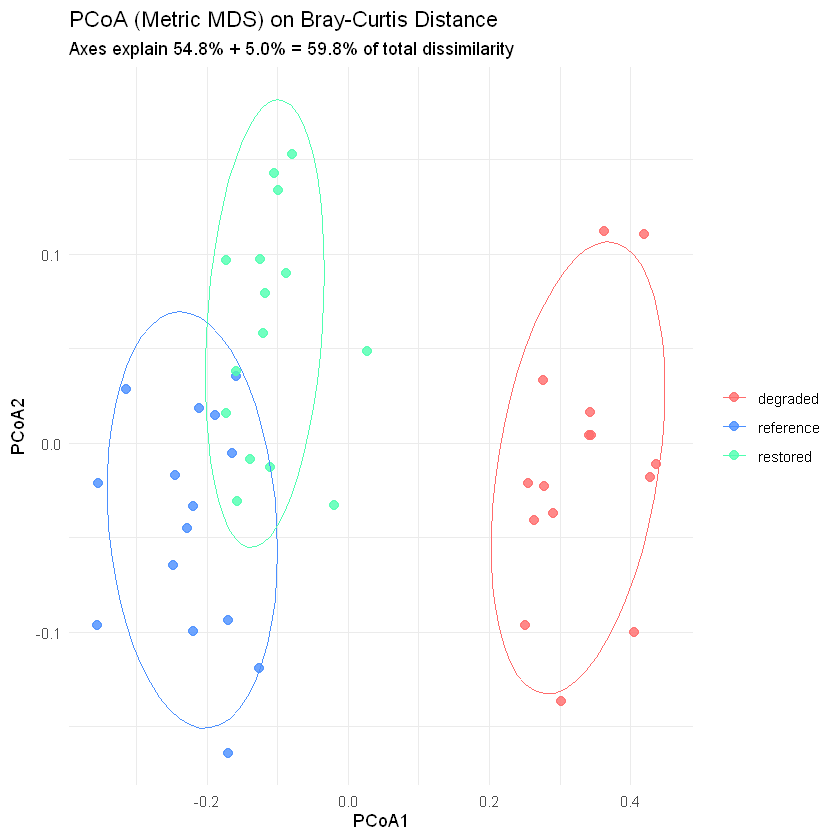

In [6]:
# ── PCoA: metric MDS preserving actual distances ──────────────────────────────
pcoa_fit <- vegan::wcmdscale(bray_dist, k=2, eig=TRUE)

pcoa_var <- pcoa_fit$eig / sum(abs(pcoa_fit$eig))
cat(sprintf("PCoA Axis 1: %.1f%% | Axis 2: %.1f%%\n",
            pcoa_var[1]*100, pcoa_var[2]*100))

pcoa_df <- as_tibble(pcoa_fit$points) %>%
  setNames(c("PCoA1","PCoA2")) %>%
  bind_cols(site_meta)

ggplot(pcoa_df, aes(x=PCoA1, y=PCoA2, color=type)) +
  geom_point(size=2.5, alpha=0.8) +
  stat_ellipse(level=0.85) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ff6b6b")) +
  labs(title="PCoA (Metric MDS) on Bray-Curtis Distance",
       subtitle=sprintf("Axes explain %.1f%% + %.1f%% = %.1f%% of total dissimilarity",
                        pcoa_var[1]*100, pcoa_var[2]*100,
                        (pcoa_var[1]+pcoa_var[2])*100),
       color=NULL) +
  theme_minimal()

# ── PERMANOVA: test whether groups differ in multivariate space ───────────────
perm_result <- vegan::adonis2(
  bray_dist ~ type,
  data         = site_meta,
  permutations = 999,
  by           = "margin"
)
cat("\nPERMANOVA (adonis2):\n")
print(perm_result)
# R2: proportion of total dissimilarity explained by group
# Pr(>F): permutation p-value

---

## Common Pitfalls

**1. Using nMDS without checking stress and the Shepard diagram**  
Always report nMDS stress and examine the Shepard diagram. Stress > 0.20 means the 2D ordination is a poor representation of the dissimilarity structure — interpret with caution or increase to k=3 dimensions. Never present an nMDS figure without the stress value.

**2. Interpreting nMDS axes as if they have directional meaning**  
nMDS axes are arbitrary — the ordination can be rotated, reflected, or rescaled without changing the rank-order preservation. Statements like "sites move along Axis 1 from degraded to reference" are only valid when an environmental gradient has been formally fitted with `envfit()`.

**3. Applying PERMANOVA without checking dispersion homogeneity**  
PERMANOVA (`adonis2`) tests whether group centroids differ in multivariate space, but it is sensitive to differences in within-group dispersion. Always run `betadisper()` + `permutest()` first. If groups have unequal dispersions, a significant PERMANOVA result may reflect dispersion differences rather than centroid differences.

**4. Using Euclidean distance for species abundance data**  
Euclidean distance is dominated by absolute abundance differences and treats double-zeros (species absent from both sites) as evidence of similarity. Bray-Curtis ignores double zeros and is proportionally scaled. For presence-absence data, Jaccard or Sørensen are preferred. Use `vegan::vegdist()` with the appropriate method.

**5. Running nMDS once with a single random start**  
nMDS is an iterative algorithm that can converge to local minima. Always use `trymax ≥ 50` in `metaMDS()` to run multiple random starts. If different starts produce substantially different stress values, the solution is unstable and results should be interpreted with caution.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*